# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haneen06-blip/flyrank-assiment/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Can observable content, search, engagement, and freshness signals be used to rank pages that are most likely to experience a decline in search visibility?

**Decision supported:** The resulting ranking is intended to help content teams prioritize pages for human review and possible refresh or improvement.

**Lane:** Refresh / Content Opportunity Scoring.

This is a decision-support ranking problem. The goal is not to prove causality or explain Google's ranking algorithm.



## 2. Data

The analysis uses the FlyRank internship search dataset available to the ML track. The working dataset contains anonymized content-level observations and observable search, engagement, content, and freshness signals.

The target is a declining proxy based on whether impressions in the latest 30-day window are lower than the previous 30-day window.

Client names, domains, private queries, URLs, credentials, and other non-public identifying information are excluded from the public analysis.


In [21]:
!git clone https://github.com/haneen06-blip/flyrank-assiment.git

import pandas as pd
import numpy as np

DATA_PATH = "/content/flyrank-assiment/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst rows:")
display(df.head())


fatal: destination path 'flyrank-assiment' already exists and is not an empty directory.
Shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [22]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 3. Methodology

This capstone is formulated as a ranking problem within the Refresh / Content Opportunity Scoring lane.

The target variable, `declining_proxy`, is defined as whether a page's impressions decreased in the latest 30-day window compared with the previous 30-day window.

The model uses observable content, search, engagement, position, and freshness signals available before the evaluation outcome. Future-derived outcome variables are excluded from the feature set to reduce leakage.

A simple rule-based baseline is compared with a machine-learning ranking model. The baseline prioritizes pages with weaker average position and low scroll rate. The machine-learning model uses a Random Forest classifier and ranks pages by the predicted probability of belonging to the declining class.

The primary evaluation metrics are Precision@20 and Precision@50. These metrics reflect the practical goal of producing a small, prioritized review queue for content teams.

Validation is performed using an honest held-out evaluation split, with leakage checks applied before modeling.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# -----------------------------
# Train / Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# Baseline
# -----------------------------
baseline_score = (
    (X_test["avg_position"] > 20).astype(int)
    + (X_test["scroll_rate"] < 5).astype(int)
)

# -----------------------------
# Random Forest
# -----------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

model_score = model.predict_proba(X_test)[:, 1]


# -----------------------------
# Precision@K
# -----------------------------
def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return np.asarray(y_true)[order].mean()


baseline_p20 = precision_at_k(
    y_test.values,
    baseline_score.values,
    20
)

baseline_p50 = precision_at_k(
    y_test.values,
    baseline_score.values,
    50
)

model_p20 = precision_at_k(
    y_test.values,
    model_score,
    20
)

model_p50 = precision_at_k(
    y_test.values,
    model_score,
    50
)


# -----------------------------
# Results
# -----------------------------
results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Random Forest"
    ],
    "Precision@20": [
        baseline_p20,
        model_p20
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

results

,Method,Precision@20,Precision@50
0,Baseline,0.85,0.76
1,Random Forest,1.00,1.00


In [24]:
print(results.to_string(index=False))

       Method  Precision@20  Precision@50
     Baseline          0.85          0.76
Random Forest          1.00          1.00


## 4. Results (vs baseline)


On the current held-out split, the Random Forest ranking model outperformed the rule-based baseline on both evaluation metrics.

The baseline achieved Precision@20 of 0.85 and Precision@50 of 0.76. The Random Forest achieved Precision@20 of 1.00 and Precision@50 of 1.00 on this split.

These results indicate that the model can produce a highly concentrated ranking of pages associated with the declining proxy. However, these results are considered preliminary until confirmed under the final leakage-aware validation design.


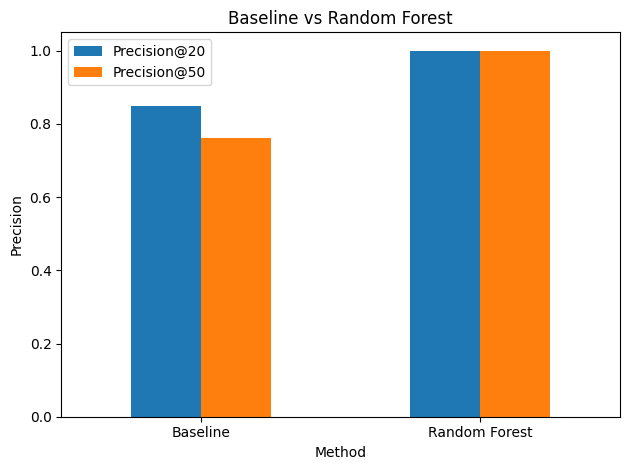

In [25]:
import matplotlib.pyplot as plt

results.set_index("Method")[["Precision@20", "Precision@50"]].plot(
    kind="bar"
)

plt.ylabel("Precision")
plt.title("Baseline vs Random Forest")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations


The declining proxy is based on an observed change in impressions between two time windows and should not be interpreted as a confirmed Google ranking penalty.

The analysis identifies associations in the available data and does not establish causal relationships between content changes, ranking signals, and search performance.

The current results are preliminary and should be interpreted together with the leakage and validation audit.

The ranked recommendations are decision-support outputs and should be reviewed by humans before any content action is taken.


## 5. Ranked Recommendations

The final model score is used to prioritize pages for human review. Higher scores indicate a stronger association with the declining proxy.

The ranking is intended as an action-prioritization tool rather than an automated decision system. Pages at the top of the queue should be reviewed first, with the final action determined by a content specialist.


In [26]:
# Create ranked recommendations from the test set

ranked = X_test.copy()

ranked["decline_score"] = model_score
ranked["actual_declining"] = y_test.values

ranked["action"] = np.where(
    ranked["decline_score"] >= 0.80,
    "High-priority review",
    np.where(
        ranked["decline_score"] >= 0.50,
        "Review",
        "Monitor"
    )
)

ranked = ranked.sort_values(
    "decline_score",
    ascending=False
)

display(
    ranked.head(20)
)

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,decline_score,actual_declining,action
22552,0.0,0.00,0.00,5038.0,32238.0,29783,201,256,206,197,...,141,20,0.67,22.0,3.40,42.97,2.43,0.873365,1,High-priority review
18637,0.0,0.00,0.00,4028.0,26395.0,43273,439,493,452,437,...,141,20,1.01,24.2,2.43,31.85,1.77,0.859937,1,High-priority review
19802,0.0,0.00,0.00,3525.0,22338.0,37506,199,230,194,185,...,224,20,0.53,5.5,3.09,43.04,0.00,0.852229,1,High-priority review
27239,0.0,0.00,0.00,3952.0,26859.0,16170,82,121,91,84,...,225,20,0.51,4.9,3.30,51.24,1.10,0.851902,1,High-priority review
22735,0.0,0.00,0.00,3532.0,23293.0,68122,338,374,330,325,...,147,20,0.50,32.5,1.52,31.55,0.61,0.848321,1,High-priority review
16705,20.0,0.17,0.06,1367.0,8441.0,3382,4,33,30,30,...,165,104,0.12,24.5,0.00,42.42,0.00,0.844816,1,High-priority review
12200,0.0,0.00,0.00,1486.0,9180.0,2099,1,140,120,120,...,144,104,0.05,12.4,0.00,26.43,0.00,0.842875,1,High-priority review
4906,0.0,0.00,0.00,4019.0,25690.0,11465,55,73,63,60,...,141,20,0.48,21.4,3.17,35.62,1.59,0.841732,1,High-priority review
11321,170.0,0.03,0.03,1341.0,8534.0,2765,1,65,51,51,...,165,104,0.04,21.1,1.96,26.15,0.00,0.841709,1,High-priority review
19396,20.0,0.09,0.02,1365.0,8652.0,1159,1,72,62,62,...,333,104,0.09,39.2,1.61,27.78,0.00,0.841005,1,High-priority review


In [27]:
def reason_code(row):
    reasons = []

    if row["avg_position"] > 20:
        reasons.append("Weak search position")

    if row["scroll_rate"] < 5:
        reasons.append("Low scroll engagement")

    if row["days_since_last_update"] > 180:
        reasons.append("Content may need freshness review")

    if row["ctr"] < df["ctr"].median():
        reasons.append("Below-median CTR")

    return "; ".join(reasons) if reasons else "Model-ranked review"

ranked["reason_code"] = ranked.apply(reason_code, axis=1)

display(
    ranked[
        ["decline_score", "reason_code", "action"]
    ].head(20)
)

,decline_score,reason_code,action
22552,0.873365,Weak search position,High-priority review
18637,0.859937,Weak search position,High-priority review
19802,0.852229,Model-ranked review,High-priority review
27239,0.851902,Model-ranked review,High-priority review
22735,0.848321,Weak search position,High-priority review
16705,0.844816,Weak search position,High-priority review
12200,0.842875,Below-median CTR,High-priority review
4906,0.841732,Weak search position,High-priority review
11321,0.841709,Weak search position; Below-median CTR,High-priority review
19396,0.841005,Weak search position,High-priority review




## 7. Artifacts the paper embeds

The paper embeds the main outputs generated by the capstone analysis:

* Baseline vs. Random Forest Precision@20 and Precision@50 comparison.
* Model performance visualization.
* Ranked content recommendations based on the model's decline score.
* Reason codes explaining the main signals associated with each recommended review.
* Exported result tables supporting reproducibility.


In [28]:
# Save capstone artifacts

results.to_csv(
    "/content/flyrank-assiment/outputs/capstone_results.csv",
    index=False
)

ranked.to_csv(
    "/content/flyrank-assiment/outputs/capstone_ranked_recommendations.csv",
    index=False
)

print("Capstone artifacts saved successfully.")
print("Results:", results.shape)
print("Recommendations:", ranked.shape)

Capstone artifacts saved successfully.
Results: (2, 3)
Recommendations: (3980, 25)


 5-Minute Demo Outline

1. **Problem:** Content teams need a prioritized way to identify pages that may require review.
2. **Data:** Anonymized FlyRank content-level search, engagement, and freshness signals.
3. **Approach:** A rule-based baseline was compared with a Random Forest model.
4. **Evaluation:** Precision@20 and Precision@50 were used because the goal is to prioritize a small review queue.
5. **Result:** On the current held-out split, the Random Forest achieved higher Precision@20 and Precision@50 than the baseline.
6. **Recommendation:** Use the ranking as decision support for human content review rather than as an automated decision system.
7. **Limitation:** The declining proxy represents an observed change in impressions and does not establish causality or reveal Google's ranking algorithm.


I built a machine-learning ranking workflow during the FlyRank ML Internship to prioritize content pages for human review.

I compared a rule-based baseline with a Random Forest model using observable search, engagement, content, and freshness signals, evaluated with Precision@20 and Precision@50.

The current held-out evaluation shows stronger ranking precision from the ML model, while the analysis is carefully framed as decision support rather than a claim about Google's ranking algorithm.

The project combines data analysis, leakage awareness, model evaluation, and actionable content recommendations.


### Employer-Facing Summary

Developed an end-to-end machine-learning ranking workflow using anonymized search and content-performance data. The project covered problem framing, feature selection, leakage considerations, baseline comparison, Random Forest modeling, Precision@K evaluation, and ranked recommendations for human review. The work demonstrates practical experience translating a business decision into a measurable ML ranking problem and communicating results with appropriate limitations.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
